In [1]:
# Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix


from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance

In [2]:
# Load the data
data = load_iris(as_frame=True)
df = data.frame
print(data.feature_names)
print(data.target_names)
print(type(data.target))
print(data.target)
print(np.unique(data.target))

X = data.data
y = data.target

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']
<class 'pandas.core.series.Series'>
0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64
[0 1 2]


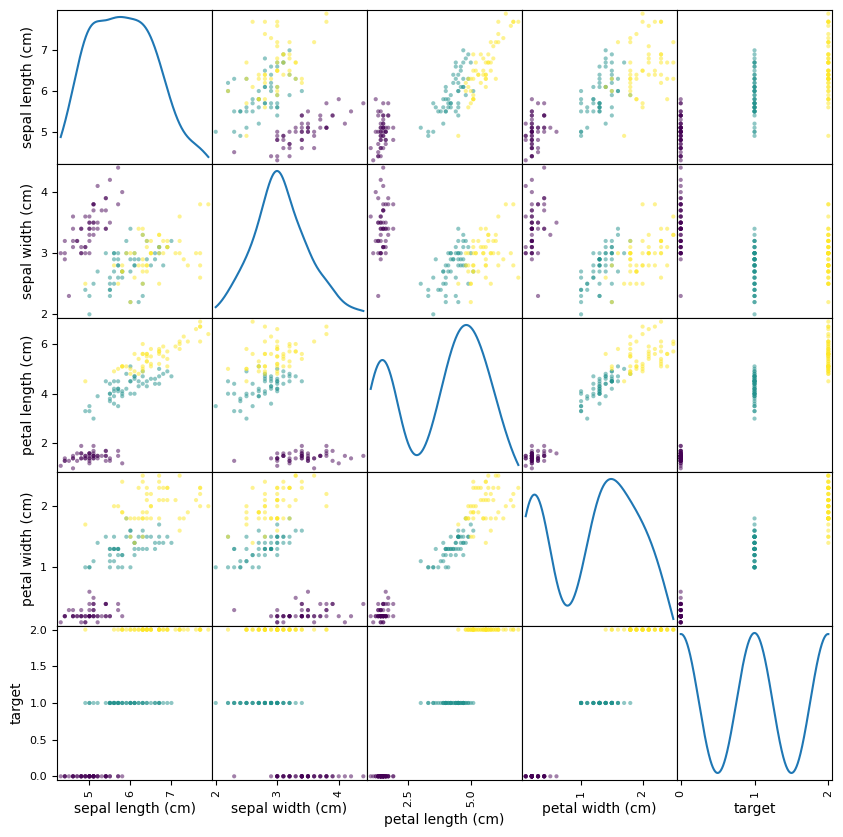

In [3]:
# Show scatter plot matrix
scatter_matrix(df, figsize=(10,10), diagonal='kde', c= y, cmap='viridis')
plt.show()

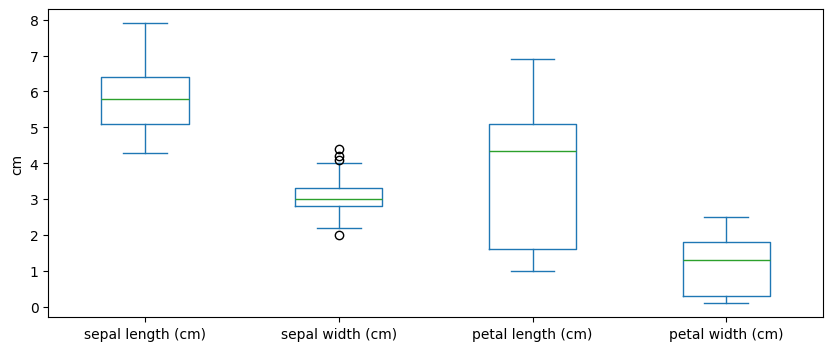

In [4]:
# Show boxplot
df.iloc[:, :-1].plot.box(figsize=(10,4), ylabel='cm')
plt.show()

In [5]:
# Show basic statistics
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



We observe that the different classes are quite well separated, there are not many outliers (only in sepal width), and the dataset is perfectly balanced. The variables have similar scales and, moreover, petal length and petal width show greater variability, suggesting they may be more informative for classification.

No data normalization will be performed, as the techniques used (decision trees and random forests) do not require it.


In [6]:
# Split the dataset into training and test data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

In [7]:
results = []
for depth in range(1, 9):
    modelo = DecisionTreeClassifier(max_depth=depth, random_state=42)
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    metrica = {
    "max_depth": depth,
    "accuracy": accuracy_score(y_test, y_pred),
    "confusion_matrix": confusion_matrix(y_test, y_pred),
    "classification_report": classification_report(y_test, y_pred, output_dict=True, zero_division=0)}
    results.append(metrica)

results


[{'max_depth': 1,
  'accuracy': 0.6333333333333333,
  'confusion_matrix': array([[10,  0,  0],
         [ 0,  9,  0],
         [ 0, 11,  0]]),
  'classification_report': {'0': {'precision': 1.0,
    'recall': 1.0,
    'f1-score': 1.0,
    'support': 10.0},
   '1': {'precision': 0.45,
    'recall': 1.0,
    'f1-score': 0.6206896551724138,
    'support': 9.0},
   '2': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 11.0},
   'accuracy': 0.6333333333333333,
   'macro avg': {'precision': 0.48333333333333334,
    'recall': 0.6666666666666666,
    'f1-score': 0.5402298850574713,
    'support': 30.0},
   'weighted avg': {'precision': 0.4683333333333334,
    'recall': 0.6333333333333333,
    'f1-score': 0.5195402298850574,
    'support': 30.0}}},
 {'max_depth': 2,
  'accuracy': 0.9666666666666667,
  'confusion_matrix': array([[10,  0,  0],
         [ 0,  8,  1],
         [ 0,  0, 11]]),
  'classification_report': {'0': {'precision': 1.0,
    'recall': 1.0,
    'f1-score': 1.0,
  

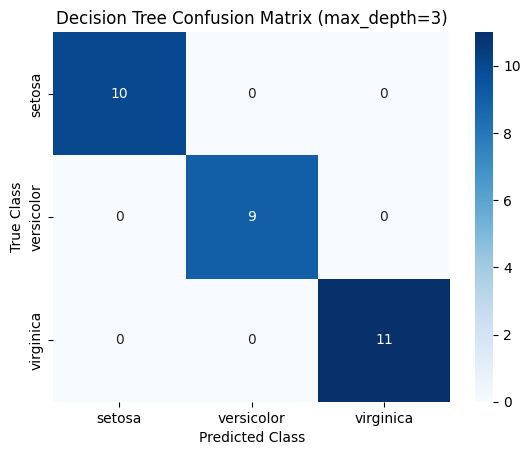

In [8]:
# Train the tree with max_depth=3
modelo = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Decision Tree Confusion Matrix (max_depth=3)")
plt.show()

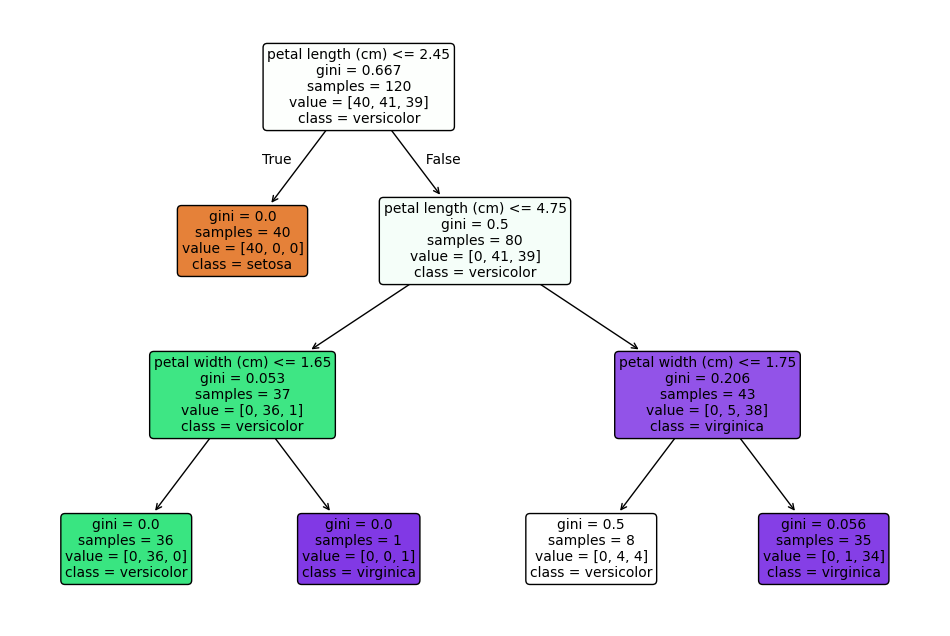

In [9]:
# Visualize the tree
plt.figure(figsize=(12,8))
plot_tree(modelo,
          feature_names=data.feature_names,
          class_names=data.target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()


The decision tree shows that Iris dataset classes can be clearly separated using petal and sepal features.
From a maximum depth of 3, the model achieves 100% accuracy on the test set,
indicating it can perfectly classify all classes without needing further depth.

Now we continue our analysis with Random Forest.

In [10]:
# Create the model and predict.
rf_modelo = RandomForestClassifier(n_estimators=100, random_state=42)
rf_modelo.fit(X_train, y_train)
y_pred_rf = rf_modelo.predict(X_test)

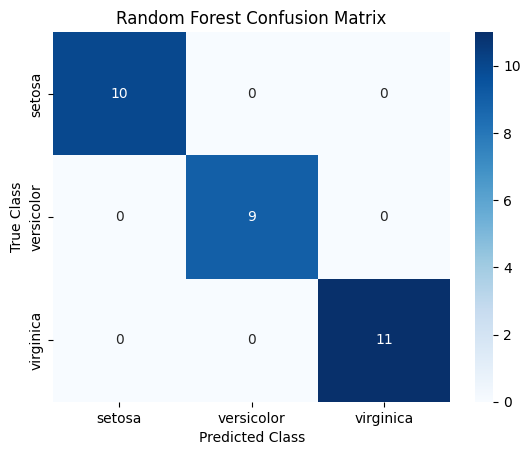

In [11]:
# Visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Random Forest Confusion Matrix")  # Fixed title
plt.show()

In [12]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_rf)
report = classification_report(y_test, y_pred_rf, output_dict=True, zero_division=0)
print("Random Forest Accuracy:", accuracy)
print("Classification report:", report)

Random Forest Accuracy: 1.0
Classification report: {'0': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 10.0}, '1': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 9.0}, '2': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 11.0}, 'accuracy': 1.0, 'macro avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 30.0}, 'weighted avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 30.0}}


Like the previous model, it achieves perfect results.

In [13]:
# Calculate feature importance
importancias = pd.Series(rf_modelo.feature_importances_, index=data.feature_names)
importancias = importancias.sort_values(ascending=False)

print(importancias)

petal length (cm)    0.439994
petal width (cm)     0.421522
sepal length (cm)    0.108098
sepal width (cm)     0.030387
dtype: float64


In [14]:
# Calculate permutation importance
result = permutation_importance(rf_modelo, X_test, y_test, n_repeats=10, random_state=42)

perm_importancias = pd.Series(result.importances_mean, index=data.feature_names)
perm_importancias = perm_importancias.sort_values(ascending=False)
print(perm_importancias)

petal length (cm)    0.25
petal width (cm)     0.22
sepal width (cm)     0.00
sepal length (cm)    0.00
dtype: float64


Both regular importance and permutation importance show that petal length and petal width are the most relevant
variables for Iris classification, while sepal dimensions contribute little to the model.